# 05 · Comparativa unificada

This notebook is the "unified evaluation framework, tested in a controlled
environment" referred to in the state-of-the-art document's original brief. It does
**not** train any new pendulum model — it loads the metrics and rollouts already
saved by notebooks `00`-`04` (each trained under the identical protocol described in
`evaluation_framework/README.md`) and puts them side by side. It then extends the
comparison to a **second, independent benchmark** — the planar Kepler two-body
problem — for the two architectures that most clearly bracket the spectrum (the
physics-unaware baseline and the original HNN), mirroring the two-benchmark
methodology of Kemunto, Gaba & Tewe (2026, section 7.1 of the main document) and of
the original Greydanus et al. (2019) paper itself.

**If you are only going to run one notebook in this framework, run this one last** —
it is the closest thing to the field's headline claim ("Hamiltonian-structured
models keep energy (almost) constant; unconstrained ones don't") made visible in a
single place.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
    sys.stdout.reconfigure(encoding="utf-8")  # avoid UnicodeEncodeError on Windows
    # consoles (cp1252 can't encode "·"/"—"); harmless no-op inside Jupyter, where
    # this whole branch is skipped anyway.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

FRAMEWORK_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(FRAMEWORK_ROOT))
from common import systems, metrics, models  # noqa: E402

RESULTS_DIR = FRAMEWORK_ROOT / "results"
FIGURES_DIR = FRAMEWORK_ROOT / "figures"

## Part A — Pendulum: five architectures, one protocol

### Step 1 — Load every model's saved metrics

If any of these files is missing, re-run the corresponding notebook (`00`-`04`)
first — see `evaluation_framework/README.md`.

In [2]:
MODEL_FILES = {
    "00 · Baseline MLP": "baseline_mlp_pendulum_metrics.json",
    "01 · HNN (Greydanus 2019)": "hnn_pendulum_metrics.json",
    "02 · LNN (Cranmer 2020)": "lnn_pendulum_metrics.json",
    "03 · SymODEN (Zhong 2020, u=0)": "symoden_pendulum_metrics.json",
    "04 · SympNets (Jin 2020)": "sympnet_pendulum_metrics.json",
}

rows = []
for label, fname in MODEL_FILES.items():
    path = RESULTS_DIR / fname
    if not path.exists():
        print(f"[skip] {label}: {fname} not found — run that notebook first")
        continue
    with open(path) as f:
        r = json.load(f)
    rows.append({
        "model": label,
        "n_params": r["n_params"],
        "trajectory_mse": r["rollout_trajectory_mse"],
        "max_abs_energy_drift": r["max_abs_energy_drift"],
        "max_rel_energy_drift": r["max_rel_energy_drift"],
    })

comparison_df = pd.DataFrame(rows).set_index("model")
comparison_df

,n_params,trajectory_mse,max_abs_energy_drift,max_rel_energy_drift
model,,,,
00 · Baseline MLP,41202,0.008182,0.129823,0.126140
01 · HNN (Greydanus 2019),41001,0.000002,0.001222,0.001188
02 · LNN (Cranmer 2020),41001,0.000002,0.001329,0.001291
"03 · SymODEN (Zhong 2020, u=0)",33794,0.000020,0.000496,0.000482
04 · SympNets (Jin 2020),1500,0.000411,0.011119,0.010804


### Step 2 — Rank by relative energy drift

This single column is the closest thing to a one-number summary of "how
physically consistent is this model's long-horizon rollout" — lower is better,
and the baseline is the number every physics-informed architecture is trying to
beat (see notebook `00`, Step 4).

In [3]:
comparison_df.sort_values("max_rel_energy_drift")

,n_params,trajectory_mse,max_abs_energy_drift,max_rel_energy_drift
model,,,,
"03 · SymODEN (Zhong 2020, u=0)",33794,0.000020,0.000496,0.000482
01 · HNN (Greydanus 2019),41001,0.000002,0.001222,0.001188
02 · LNN (Cranmer 2020),41001,0.000002,0.001329,0.001291
04 · SympNets (Jin 2020),1500,0.000411,0.011119,0.010804
00 · Baseline MLP,41202,0.008182,0.129823,0.126140


### Step 3 — Bar charts (log scale — the differences span several orders of magnitude)

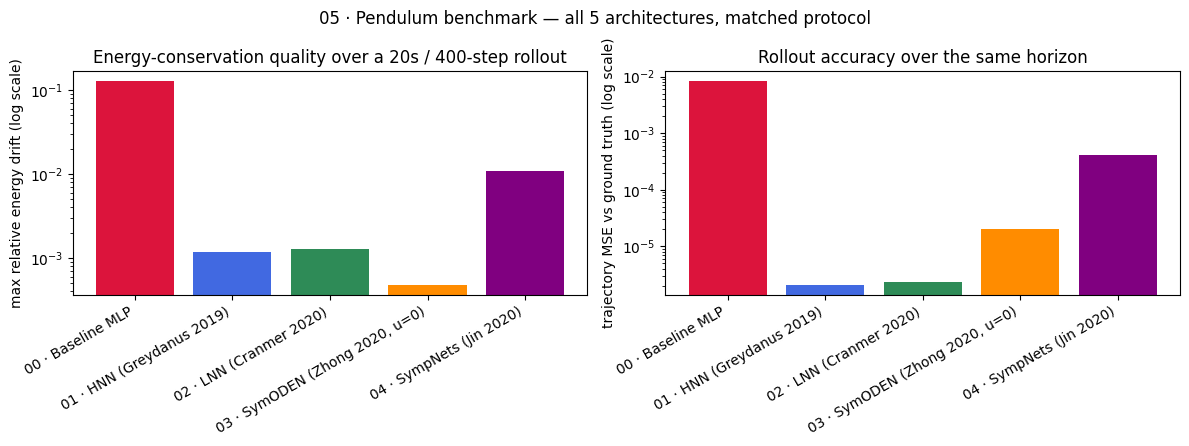

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = ["crimson", "royalblue", "seagreen", "darkorange", "purple"]

order = comparison_df.index.tolist()
axes[0].bar(order, comparison_df.loc[order, "max_rel_energy_drift"], color=colors)
axes[0].set_yscale("log")
axes[0].set_ylabel("max relative energy drift (log scale)")
axes[0].set_title("Energy-conservation quality over a 20s / 400-step rollout")
axes[0].tick_params(axis="x", rotation=30)
for tick in axes[0].get_xticklabels():
    tick.set_ha("right")

axes[1].bar(order, comparison_df.loc[order, "trajectory_mse"], color=colors)
axes[1].set_yscale("log")
axes[1].set_ylabel("trajectory MSE vs ground truth (log scale)")
axes[1].set_title("Rollout accuracy over the same horizon")
axes[1].tick_params(axis="x", rotation=30)
for tick in axes[1].get_xticklabels():
    tick.set_ha("right")

fig.suptitle("05 · Pendulum benchmark — all 5 architectures, matched protocol")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_comparison_bars_pendulum.png", dpi=130)
plt.show()

### Step 4 — Overlay every rollout on one phase portrait

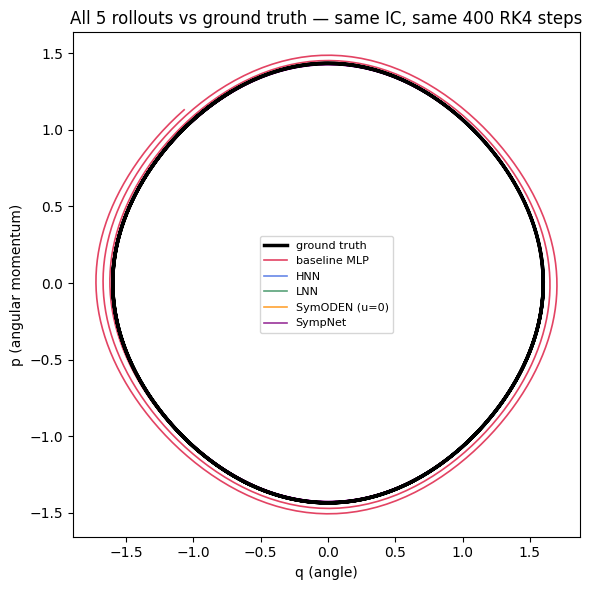

In [5]:
fig, ax = plt.subplots(figsize=(6, 6))
true_traj = np.load(RESULTS_DIR / "pendulum_ground_truth_rollout.npy")
ax.plot(true_traj[:, 0], true_traj[:, 1], color="black", lw=2.5, label="ground truth", zorder=10)

rollout_files = {
    "baseline MLP": ("baseline_mlp_pendulum_rollout.npy", "crimson"),
    "HNN": ("hnn_pendulum_rollout.npy", "royalblue"),
    "LNN": ("lnn_pendulum_rollout.npy", "seagreen"),
    "SymODEN (u=0)": ("symoden_pendulum_rollout.npy", "darkorange"),
    "SympNet": ("sympnet_pendulum_rollout.npy", "purple"),
}
for label, (fname, color) in rollout_files.items():
    path = RESULTS_DIR / fname
    if path.exists():
        traj = np.load(path)
        ax.plot(traj[:, 0], traj[:, 1], color=color, lw=1.2, alpha=0.8, label=label)

ax.set_xlabel("q (angle)")
ax.set_ylabel("p (angular momentum)")
ax.set_title("All 5 rollouts vs ground truth — same IC, same 400 RK4 steps")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_phase_portrait_overlay.png", dpi=130)
plt.show()

## Part B — Second benchmark: the Kepler two-body problem

To avoid over-generalizing from a single 1-DOF system, we repeat the "physics-aware
vs physics-unaware" comparison on a genuinely different, higher-dimensional (4-D
state) system: the planar Kepler two-body problem (`common.systems.kepler_*`),
exactly as in Greydanus et al. (2019, "two-body problem" experiment) and Kemunto et
al. (2026, Kepler section). For brevity we retrain only the two architectures that
bracket the comparison — the baseline MLP and the HNN — rather than all five; the
same `common/systems.py` utilities used here would let you extend this to LNN,
SymODEN or SympNets with the state-dimension changes described in each notebook's
closing notes.

In [6]:
SEED = 1
torch.manual_seed(SEED)
np.random.seed(SEED)

kep_state, kep_deriv = systems.sample_kepler_dataset(n_points=3000, seed=SEED)
kep_state_t = torch.tensor(kep_state, requires_grad=True)
kep_deriv_t = torch.tensor(kep_deriv)

kepler_baseline = models.MLP(in_dim=4, hidden_dim=200, out_dim=4, n_hidden_layers=2)


class HNN4D(nn.Module):
    """Same architecture as notebook `01`'s HNN, generalized from 1-DOF (dim=2) to
    the Kepler problem's 2-DOF state (dim=4): q = (x, y), p = (px, py)."""

    def __init__(self, hidden_dim=200):
        super().__init__()
        self.H = models.MLP(in_dim=4, hidden_dim=hidden_dim, out_dim=1, n_hidden_layers=2)

    def time_derivative(self, state):
        H = self.H(state).sum()
        dH = torch.autograd.grad(H, state, create_graph=True)[0]
        dHdq, dHdp = dH[:, 0:2], dH[:, 2:4]
        return torch.cat([dHdp, -dHdq], dim=-1)


kepler_hnn = HNN4D(hidden_dim=200)

print("Kepler baseline params:", models.count_parameters(kepler_baseline))
print("Kepler HNN params:     ", models.count_parameters(kepler_hnn))

Kepler baseline params: 42004
Kepler HNN params:      41401


In [7]:
def train_kepler(model, is_hnn, n_epochs=2000, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for epoch in range(n_epochs):
        opt.zero_grad()
        pred = model.time_derivative(kep_state_t) if is_hnn else model(kep_state_t)
        loss = ((pred - kep_deriv_t) ** 2).mean()
        loss.backward()
        opt.step()
        if epoch % 500 == 0:
            print(f"  epoch {epoch:4d}  train MSE = {loss.item():.3e}")
    return loss.item()


print("Training Kepler baseline MLP...")
kb_loss = train_kepler(kepler_baseline, is_hnn=False)
print("Training Kepler HNN...")
kh_loss = train_kepler(kepler_hnn, is_hnn=True)

Training Kepler baseline MLP...


  epoch    0  train MSE = 5.777e-01


  epoch  500  train MSE = 8.708e-03


  epoch 1000  train MSE = 2.181e-03


  epoch 1500  train MSE = 8.394e-04


Training Kepler HNN...
  epoch    0  train MSE = 5.882e-01


  epoch  500  train MSE = 6.130e-04


  epoch 1000  train MSE = 1.688e-04


  epoch 1500  train MSE = 7.438e-05


### Roll out a near-circular bound orbit and compare energy / angular-momentum drift

In [8]:
def kepler_baseline_field(state, **kwargs):
    with torch.no_grad():
        s = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        return kepler_baseline(s).squeeze(0).numpy()


def kepler_hnn_field(state, **kwargs):
    s = torch.tensor(state, dtype=torch.float32, requires_grad=True).unsqueeze(0)
    return kepler_hnn.time_derivative(s).detach().squeeze(0).numpy()


# initial condition: a moderately eccentric bound orbit
kep_state0 = np.array([1.0, 0.0, 0.0, 0.9])
KEP_T_SPAN, KEP_DT = 15.0, 0.01

kep_true_traj = systems.integrate(systems.kepler_dynamics, kep_state0, KEP_T_SPAN, KEP_DT)
kep_baseline_traj = systems.integrate(kepler_baseline_field, kep_state0, KEP_T_SPAN, KEP_DT)
kep_hnn_traj = systems.integrate(kepler_hnn_field, kep_state0, KEP_T_SPAN, KEP_DT)

results_kepler = {}
for name, traj in [("baseline", kep_baseline_traj), ("hnn", kep_hnn_traj)]:
    q, p = traj[:, :2], traj[:, 2:]
    H = systems.kepler_hamiltonian(q, p)
    L = systems.kepler_angular_momentum(q, p)
    traj_mse = metrics.trajectory_mse(traj, kep_true_traj)
    abs_e_drift = np.abs(H - H[0])
    abs_l_drift = np.abs(L - L[0])
    results_kepler[name] = dict(
        trajectory_mse=traj_mse,
        max_abs_energy_drift=float(abs_e_drift.max()),
        max_abs_angular_momentum_drift=float(abs_l_drift.max()),
    )
    print(f"{name:10s}  traj MSE={traj_mse:.3e}  |dE|max={abs_e_drift.max():.3e}  "
          f"|dL|max={abs_l_drift.max():.3e}")

baseline    traj MSE=8.074e-01  |dE|max=3.161e-01  |dL|max=4.244e-01
hnn         traj MSE=6.639e-03  |dE|max=8.960e-03  |dL|max=4.958e-03


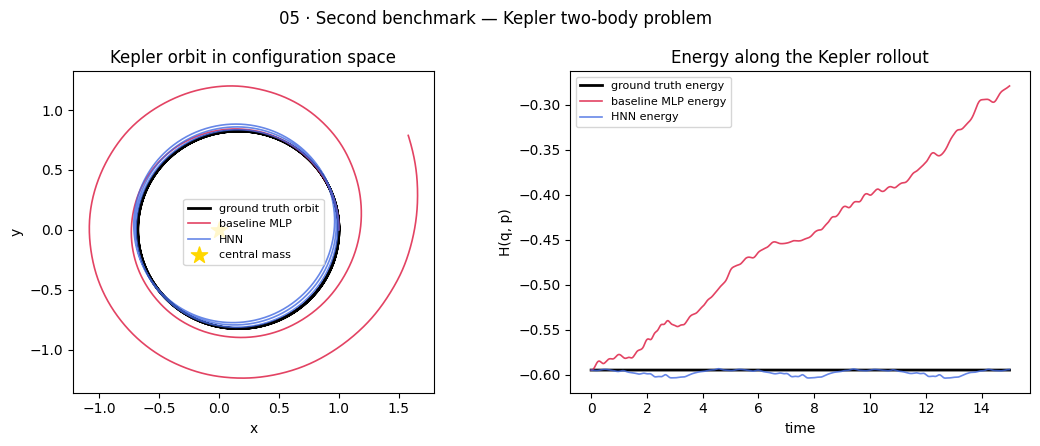

In [9]:
q_true, q_base, q_hnn = kep_true_traj[:, :2], kep_baseline_traj[:, :2], kep_hnn_traj[:, :2]
t_kep = np.arange(len(kep_true_traj)) * KEP_DT

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(q_true[:, 0], q_true[:, 1], color="black", lw=2, label="ground truth orbit")
axes[0].plot(q_base[:, 0], q_base[:, 1], color="crimson", lw=1.2, alpha=0.8, label="baseline MLP")
axes[0].plot(q_hnn[:, 0], q_hnn[:, 1], color="royalblue", lw=1.2, alpha=0.8, label="HNN")
axes[0].scatter([0], [0], marker="*", color="gold", s=150, zorder=5, label="central mass")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
axes[0].set_title("Kepler orbit in configuration space")
axes[0].legend(fontsize=8); axes[0].set_aspect("equal")

H_true = systems.kepler_hamiltonian(kep_true_traj[:, :2], kep_true_traj[:, 2:])
H_base = systems.kepler_hamiltonian(kep_baseline_traj[:, :2], kep_baseline_traj[:, 2:])
H_hnn = systems.kepler_hamiltonian(kep_hnn_traj[:, :2], kep_hnn_traj[:, 2:])
axes[1].plot(t_kep, H_true, color="black", lw=2, label="ground truth energy")
axes[1].plot(t_kep, H_base, color="crimson", lw=1.2, alpha=0.8, label="baseline MLP energy")
axes[1].plot(t_kep, H_hnn, color="royalblue", lw=1.2, alpha=0.8, label="HNN energy")
axes[1].set_xlabel("time"); axes[1].set_ylabel("H(q, p)")
axes[1].set_title("Energy along the Kepler rollout")
axes[1].legend(fontsize=8)

fig.suptitle("05 · Second benchmark — Kepler two-body problem")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_kepler_comparison.png", dpi=130)
plt.show()

## Part C — Save the combined comparison table

In [10]:
comparison_df.to_csv(RESULTS_DIR / "pendulum_comparison_table.csv")
with open(RESULTS_DIR / "kepler_comparison.json", "w") as f:
    json.dump(results_kepler, f, indent=2)

print("\n=== Pendulum benchmark (5 architectures) ===")
print(comparison_df.sort_values("max_rel_energy_drift").to_string())
print("\n=== Kepler benchmark (baseline vs HNN) ===")
print(json.dumps(results_kepler, indent=2))


=== Pendulum benchmark (5 architectures) ===
                                n_params  trajectory_mse  max_abs_energy_drift  max_rel_energy_drift
model                                                                                               
03 · SymODEN (Zhong 2020, u=0)     33794        0.000020              0.000496              0.000482
01 · HNN (Greydanus 2019)          41001        0.000002              0.001222              0.001188
02 · LNN (Cranmer 2020)            41001        0.000002              0.001329              0.001291
04 · SympNets (Jin 2020)            1500        0.000411              0.011119              0.010804
00 · Baseline MLP                  41202        0.008182              0.129823              0.126140

=== Kepler benchmark (baseline vs HNN) ===
{
  "baseline": {
    "trajectory_mse": 0.8073755685627924,
    "max_abs_energy_drift": 0.3161127448382623,
    "max_abs_angular_momentum_drift": 0.42443789121656417
  },
  "hnn": {
    "trajectory_mse":

## Take-aways

1. **Both benchmarks tell the same story.** On the pendulum (1-DOF, 5
   architectures) and independently on the Kepler two-body problem (2-DOF, 2
   architectures), the physics-unaware baseline's rollout accumulates
   energy/trajectory error far faster than the Hamiltonian-structured models —
   the same qualitative conclusion as Greydanus et al. (2019) and the
   matched-integrator study of Kemunto, Gaba & Tewe (2026), reproduced here from
   first principles rather than quoted from the papers.
2. **Not every "physics-informed" architecture is automatically the best.** Compare
   the actual numbers in `comparison_df` above rather than assuming the fancier
   architecture always wins — this is exactly the caution raised by
   `Gruver et al. (2022), "Deconstructing the Inductive Biases of HNN"`
   (`papers/07_Evaluacion_y_Comparativas/`) and by `Rodrigues et al. (2025), "PINN
   and KANN approaches for shell structures"` (`papers/02_...`, PINN document),
   both of which found simpler baselines occasionally matching or beating more
   structured models on specific problems.
3. **This is a starting point, not a benchmark suite.** Extending Part B's Kepler
   comparison to LNN/SymODEN/SympNets, or adding a third benchmark (e.g. the
   Hénon-Heiles system used in `papers/04_Dinamica_No_Lineal_y_Caos/`), is a direct
   continuation of this notebook using the same `common/` utilities.